In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load your dataset
df = pd.read_csv("Demotivational.csv")

# Preview
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.353130e+09,2891,i.imgur.com,13c9i5,"""Distinction""",fudgemunk,4711,1820,59,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://e.thumbs.redditmedia.com/9qXi1nh4HzavyV...,t5_2qm1v,False,NaN,NaN,False,t3_13c9i5,http://i.imgur.com/M3b2i.png,NaN
1,1.357066e+09,2553,imgur.com,15s3nr,This demotivational is the reason why I first ...,RafTheKillJoy,5925,3372,42,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://b.thumbs.redditmedia.com/8jvXDhtQjF58U-...,t5_2qm1v,False,NaN,NaN,False,t3_15s3nr,http://imgur.com/tLY4z,NaN
2,1.353607e+09,2392,imgur.com,13mnds,The Truth,sheepsdontcry,4288,1896,73,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://c.thumbs.redditmedia.com/FbGSpS9tlH_sSq...,t5_2qm1v,False,NaN,NaN,False,t3_13mnds,http://imgur.com/CaCZc,NaN
3,1.359563e+09,2275,i.imgur.com,17kf72,Sex and Death,peteypump,4394,2119,67,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://a.thumbs.redditmedia.com/1Dr4c-1jCV4lQ1...,t5_2qm1v,False,NaN,NaN,False,t3_17kf72,http://i.imgur.com/Icsw9hN.jpg,NaN
4,1.365104e+09,2201,img.izismile.com,1bojm3,I wish this weren't so true,nthensome,3535,1334,30,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://c.thumbs.redditmedia.com/PPtKWu0sn4uAXm...,t5_2qm1v,False,NaN,NaN,False,t3_1bojm3,http://img.izismile.com/img/img6/20130326/640/...,NaN


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  947 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                0 non-null      float64
 11  link_flair_text         3 non-null      str    
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      53
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                  1000
link_flair_text            997
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class       999
author_flair_css_class     874
is_self                      0
name                         0
url                          0
distinguished             1000
dtype: int64

In [5]:
print("Columns:", df.columns.tolist())
print(df.head())

Columns: ['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups', 'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text', 'over_18', 'thumbnail', 'subreddit_id', 'edited', 'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name', 'url', 'distinguished']
Empty DataFrame
Columns: [created_utc, score, domain, id, title, author, ups, downs, num_comments, permalink, selftext, link_flair_text, over_18, thumbnail, subreddit_id, edited, link_flair_css_class, author_flair_css_class, is_self, name, url, distinguished]
Index: []


In [7]:
print(df.columns.tolist())

['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups', 'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text', 'over_18', 'thumbnail', 'subreddit_id', 'edited', 'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name', 'url', 'distinguished']


In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



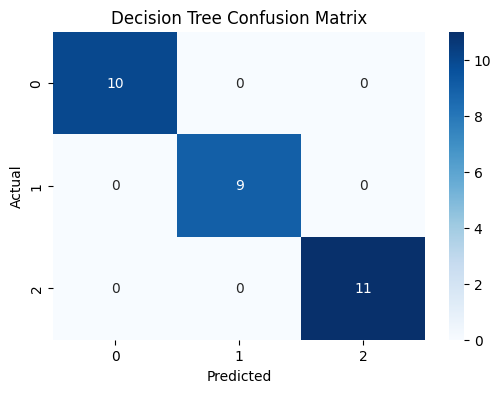

NameError: name 'y_pred_rf' is not defined

In [11]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test, y_pred_dt, "Decision Tree Confusion Matrix")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")

In [14]:
print(dir())

['DecisionTreeClassifier', 'In', 'Out', 'RandomForestClassifier', 'TfidfVectorizer', 'X', 'X_test', 'X_train', '_', '_2', '_3', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__session__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'accuracy_score', 'classification_report', 'confusion_matrix', 'data', 'df', 'dt_model', 'exit', 'get_ipython', 'load_iris', 'np', 'open', 'pd', 'plot_conf_matrix', 'plt', 'quit', 'sns', 'train_test_split', 'vectorizer', 'y', 'y_pred_dt', 'y_test', 'y_train']
